In [253]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize as opt

In [ ]:

# if not os.path.exists("monthly_returns.csv"):

if True:

    # Tickers for asset classes
    tickers = {
        'US Equities (^GSPC)': '^GSPC',
        'US 10Yr Bonds (IEF)': 'IEF',
        'US REITs (IYR)': 'IYR',
        'Commodities (SPGSCI)': '^SPGSCI'
    }
    
    data = pd.DataFrame()

    # downloading and clean data
    for name, ticker in tickers.items():
        df = yf.download(ticker, start = '2000-01-01', end = '2023-10-01', interval='1mo')
        if df.empty:
            print(f"[Warning] No data for {name} ({ticker})")
            continue
        col = "Adj Close" if "Adj Close" in df.columns else "Close"
        data[ticker] = df[col]

    # Calculate monthly returns
    monthly_returns = data.pct_change().fillna(0)

    # Show or save result
    display(monthly_returns.head())

    # Optional: Save to CSV
    monthly_returns.to_csv("monthly_returns.csv")
    
# else:
#     # Load the monthly returns from the CSV file
#     monthly_returns = pd.read_csv("monthly_returns.csv", index_col=0, parse_dates=True)
#     monthly_returns.index = pd.to_datetime(monthly_returns.index)
    
#     display(monthly_returns.head())
    

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,^GSPC,IEF,IYR,^SPGSCI
Date,,,,
2000-01-01,0.000000,0.0,0.0,0.000000
2000-02-01,-0.020108,0.0,0.0,0.046712
2000-03-01,0.096720,0.0,0.0,-0.042267
2000-04-01,-0.030796,0.0,0.0,-0.017740
2000-05-01,-0.021915,0.0,0.0,0.098371


In [255]:
annualized_returns = (1 + monthly_returns).prod() ** (12 / len(monthly_returns)) - 1
annualized_volatility = monthly_returns.std() * np.sqrt(12)
annualized_covariance = monthly_returns.cov() * 12

display(annualized_returns)
display(annualized_volatility)
display(annualized_covariance)


^GSPC      0.048434
IEF        0.030024
IYR        0.075356
^SPGSCI    0.046667
dtype: float64

^GSPC      0.153667
IEF        0.063202
IYR        0.204623
^SPGSCI    0.229575
dtype: float64

,^GSPC,IEF,IYR,^SPGSCI
^GSPC,0.023613,-0.001352,0.021331,0.012802
IEF,-0.001352,0.003995,0.000738,-0.003267
IYR,0.021331,0.000738,0.041871,0.011118
^SPGSCI,0.012802,-0.003267,0.011118,0.052705


In [256]:
def optimization(type, returns, covariance, sharpe_ratio_condition = False, sharpe_ratio = 1):

    w = np.array([0.25, 0.25, 0.25, 0.25])
    bounds = tuple((0, 1) for _ in range(len(w)))
    weights_constraint = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    constraints = [weights_constraint]
    
    if sharpe_ratio_condition:
        returns = np.sqrt(np.diag(covariance))*sharpe_ratio
    
    # Type 1: Maximize return subject to annualized volatility less than 10%
    if type == 'volatility':
        
        target_volatility = 0.1
        constraints.append({'type': 'ineq', 'fun': lambda x: target_volatility - np.sqrt(np.dot(x.T, np.dot(covariance, x)))})
        obj = lambda x: -np.dot(x, returns)
        result = opt.minimize( obj, w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_weights = result.x
        optimal_return = -result.fun
        optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance, optimal_weights)))
        optimal_sharpe_ratio = optimal_return / optimal_volatility
    
    # Type 2: Minimize volatility subject to annualized return more than 4%
    if type == 'return':
        
        target_return = 0.04
        constraints.append({'type': 'ineq', 'fun': lambda x: np.dot(x, returns) - target_return})
        obj = lambda x: np.sqrt(np.dot(x.T, np.dot(covariance, x)))
        result = opt.minimize( obj, w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_weights = result.x
        optimal_return = np.dot(optimal_weights, returns)    
        optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance, optimal_weights)))
        optimal_sharpe_ratio = optimal_return / optimal_volatility
    
    # Type 3: Maximize Sharpe Ratio
    if type == 'sharpe_ratio':
        
        obj = lambda x: -np.dot(x, returns) / np.sqrt(np.dot(x.T, np.dot(covariance, x)))
        result = opt.minimize( obj, w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_weights = result.x
        optimal_return = np.dot(optimal_weights, returns)
        optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance, optimal_weights)))
        optimal_sharpe_ratio = -result.fun
            
    return optimal_weights, optimal_return, optimal_volatility, optimal_sharpe_ratio

In [257]:
weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance)

display("Optimal Weights (Max Return, Volatility < 10%)")
display(weights)
display("Expected Annualized Return")
display(returns)
display("Expected Annualized Volatility")
display(volatility)
display("Expected Sharpe Ratio")
display(sharpe_ratio)

'Optimal Weights (Max Return, Volatility < 10%)'

array([2.58040117e-17, 4.75050007e-01, 4.28509833e-01, 9.64401607e-02])

'Expected Annualized Return'

np.float64(0.05105380213155246)

'Expected Annualized Volatility'

np.float64(0.10000012234803052)

'Expected Sharpe Ratio'

np.float64(0.5105373966830747)

In [258]:
weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance, True, sharpe_ratio=1)

display("Optimal Weights (Max Return, Volatility < 10%)")
display(weights)

# weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance, True, sharpe_ratio=2)

# display("Optimal Weights (Max Return, Volatility < 10%)")
# display(weights)

'Optimal Weights (Max Return, Volatility < 10%)'

array([0.06348829, 0.39273029, 0.24770487, 0.29607656])

In [259]:
weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance)

display("Optimal Weights (Min Volatility, Return > 4%)")
display(weights)
display("Expected Annualized Return")
display(returns)
display("Expected Annualized Volatility")
display(volatility)
display("Expected Sharpe Ratio")
display(sharpe_ratio)

'Optimal Weights (Min Volatility, Return > 4%)'

array([0.07765215, 0.67916001, 0.15683508, 0.08635277])

'Expected Annualized Return'

np.float64(0.04000000000430619)

'Expected Annualized Volatility'

np.float64(0.06349525509455255)

'Expected Sharpe Ratio'

np.float64(0.6299683329839542)

In [260]:
weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance, True)

display("Optimal Weights (Min Volatility, Return > 4%)")
display(weights)

# weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance, True, sharpe_ratio=2)

# display("Optimal Weights (Min Volatility, Return > 4%)")
# display(weights)

'Optimal Weights (Min Volatility, Return > 4%)'

array([1.24937630e-01, 8.02577130e-01, 5.20417043e-18, 7.24852404e-02])

In [261]:
weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance)

display("Optimal Weights (Max Sharpe Ratio)")
display(weights)
display("Expected Annualized Return")
display(returns)
display("Expected Annualized Volatility")
display(volatility)
display("Expected Sharpe Ratio")
display(sharpe_ratio)

'Optimal Weights (Max Sharpe Ratio)'

array([0.12352193, 0.73987206, 0.05711104, 0.07949496])

'Expected Annualized Return'

np.float64(0.03620967526563598)

'Expected Annualized Volatility'

np.float64(0.05568547620899207)

'Expected Sharpe Ratio'

np.float64(0.6502534903309106)

In [262]:
weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance, True)

display("Optimal Weights (Max Sharpe Ratio)")
display(weights)

weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance, True, sharpe_ratio=2)

display("Optimal Weights (Max Sharpe Ratio)")
display(weights)

'Optimal Weights (Max Sharpe Ratio)'

array([0.13938158, 0.67760802, 0.03991327, 0.14309712])

'Optimal Weights (Max Sharpe Ratio)'

array([0.13929247, 0.67760561, 0.03995822, 0.1431437 ])

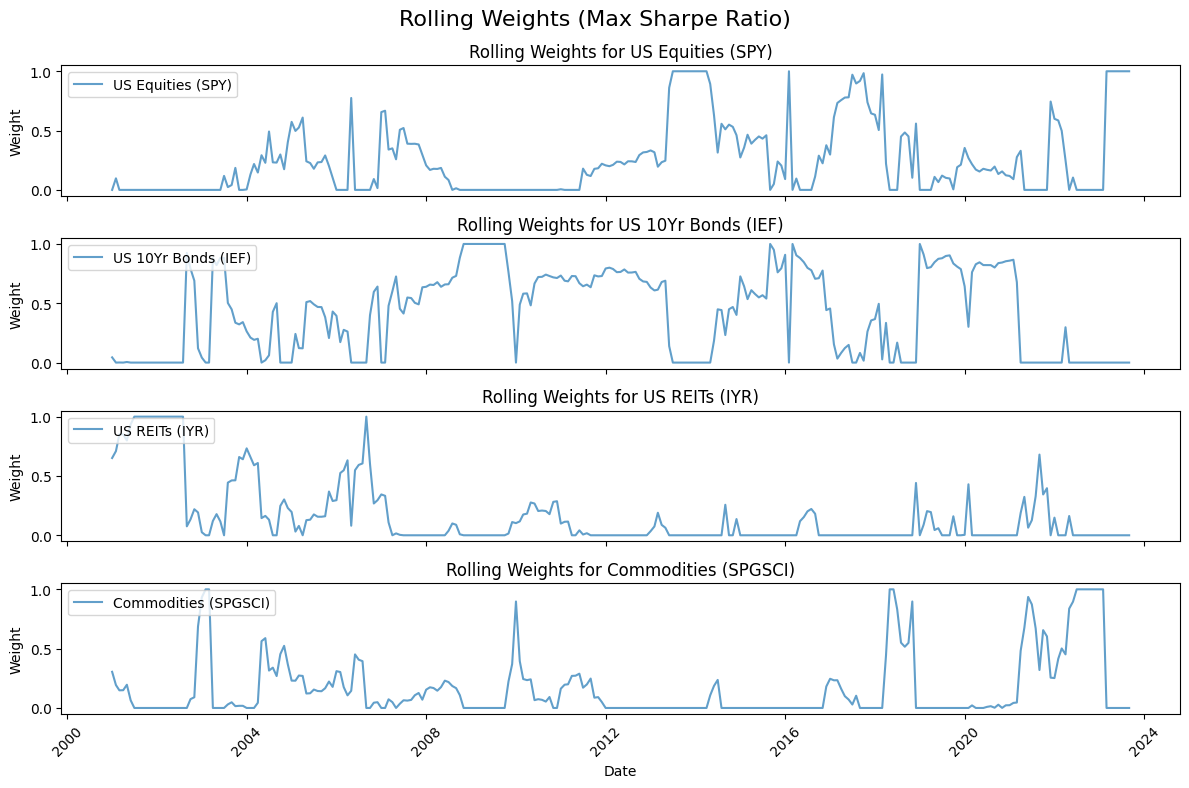

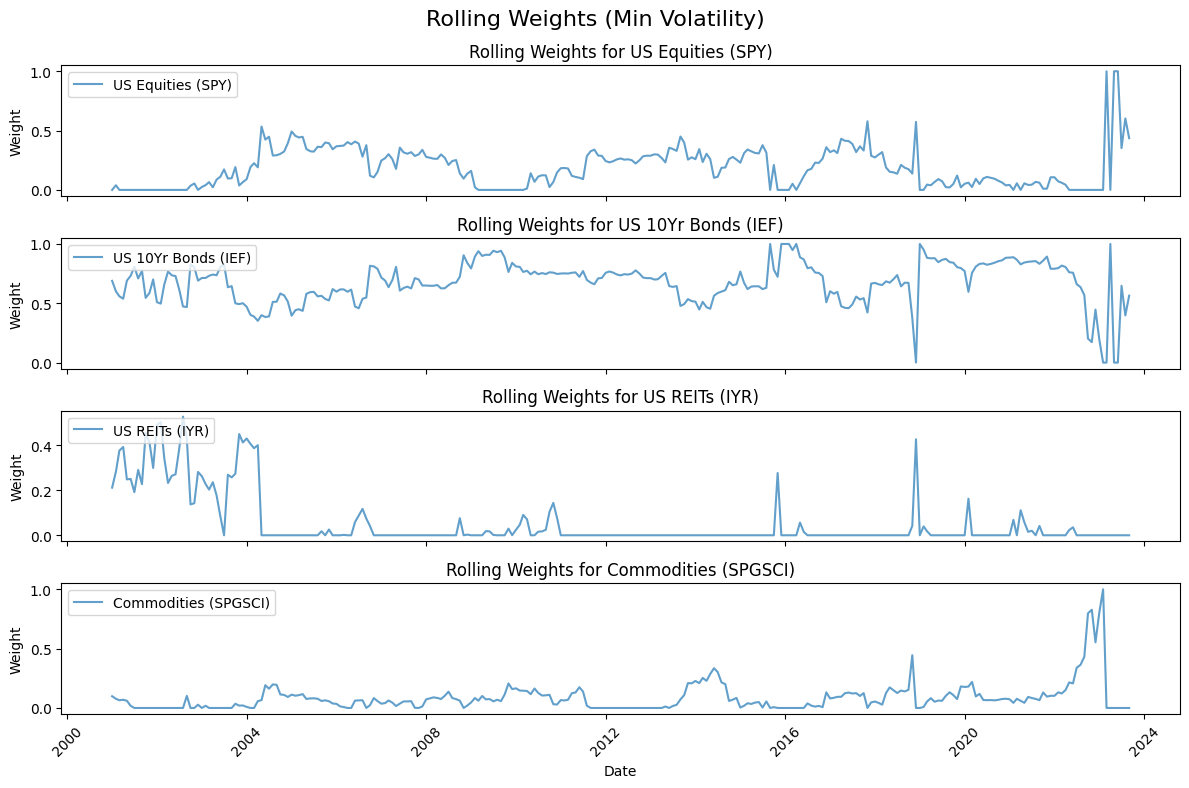

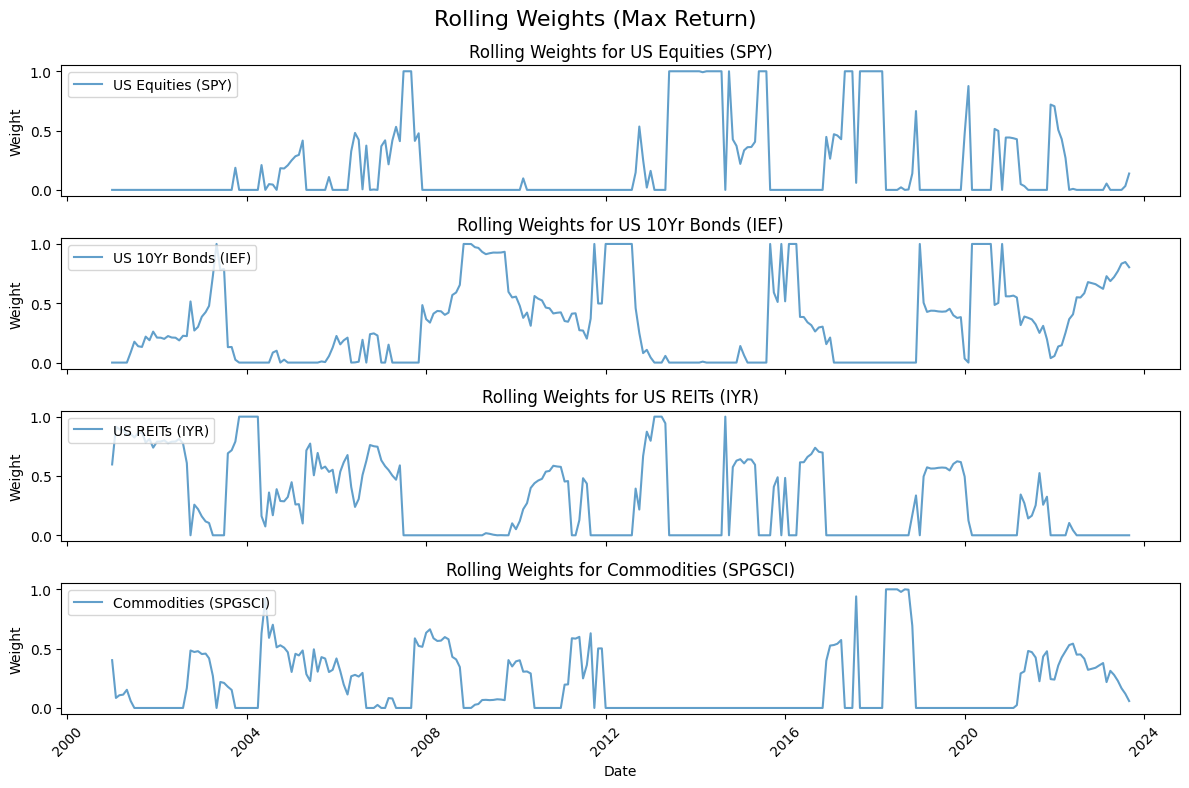

In [263]:
# Create a rolling window of 12 months calculating the optimal weights for each optimization type
rolling_window = 12
rolling_weights_sharpe_ratio = pd.DataFrame(index=monthly_returns.index[rolling_window:], columns=tickers.keys())
rolling_weights_min_volatility = pd.DataFrame(index=monthly_returns.index[rolling_window:], columns=tickers.keys())
rolling_weights_max_return = pd.DataFrame(index=monthly_returns.index[rolling_window:], columns=tickers.keys())


for i in range(rolling_window, len(monthly_returns)):
    window_data = monthly_returns.iloc[i - rolling_window:i]
    annualized_returns = (1 + window_data).prod() ** (12 / len(window_data)) - 1
    annualized_covariance = window_data.cov() * 12
    
    weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance)
    rolling_weights_sharpe_ratio.iloc[i - rolling_window] = weights
    weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance)
    rolling_weights_min_volatility.iloc[i - rolling_window] = weights
    weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance)
    rolling_weights_max_return.iloc[i - rolling_window] = weights
    
    
# Create subplots for rolling weights
fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 8), sharex=True)
fig.suptitle('Rolling Weights (Max Sharpe Ratio)', fontsize=16)

# Plot each asset's rolling weights in a separate subplot
for ax, (column, name) in zip(axes, zip(rolling_weights_sharpe_ratio.columns, tickers.keys())):
    ax.plot(rolling_weights_sharpe_ratio[column], label=name, alpha=0.7)
    ax.set_title(f'Rolling Weights for {name}')
    ax.set_ylabel('Weight')
    ax.legend(loc='upper left')

# Set common x-axis label
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create subplots for rolling weights
fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 8), sharex=True)
fig.suptitle('Rolling Weights (Min Volatility)', fontsize=16)

# Plot each asset's rolling weights in a separate subplot
for ax, (column, name) in zip(axes, zip(rolling_weights_min_volatility.columns, tickers.keys())):
    ax.plot(rolling_weights_min_volatility[column], label=name, alpha=0.7)
    ax.set_title(f'Rolling Weights for {name}')
    ax.set_ylabel('Weight')
    ax.legend(loc='upper left')

# Set common x-axis label
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Create subplots for rolling weights
fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 8), sharex=True)
fig.suptitle('Rolling Weights (Max Return)', fontsize=16)

# Plot each asset's rolling weights in a separate subplot
for ax, (column, name) in zip(axes, zip(rolling_weights_max_return.columns, tickers.keys())):
    ax.plot(rolling_weights_max_return[column], label=name, alpha=0.7)
    ax.set_title(f'Rolling Weights for {name}')
    ax.set_ylabel('Weight')
    ax.legend(loc='upper left')

# Set common x-axis label
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [264]:
def minimum_volatility_portfolio(returns):
    
    annualized_volatility = returns.std() * np.sqrt(12)
    annualized_covariance = returns.cov() * 12

    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = tuple((0, 1) for _ in range(len(returns.columns)))
    initial_weights = np.array([1 / len(returns.columns)] * len(returns.columns))

    result = opt.minimize(
        lambda x: np.sqrt(np.dot(x.T, np.dot(annualized_covariance, x))),
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    optimal_weights = result.x

    return optimal_weights


def maximum_diversification_portfolio(returns):
    
    annualized_volatility = returns.std() * np.sqrt(12)
    annualized_covariance = returns.cov() * 12

    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = tuple((0, 1) for _ in range(len(returns.columns)))
    initial_weights = np.array([1 / len(returns.columns)] * len(returns.columns))

    result = opt.minimize(
        lambda x: -np.log(np.dot(x, annualized_volatility)) + np.log(np.sqrt(np.dot(x.T, np.dot(annualized_covariance, x)))),
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    optimal_weights = result.x
    
    return optimal_weights


In [265]:
backtest_period = 36  # months
returns = pd.DataFrame()

for i in range(len(monthly_returns)):
    if i < backtest_period:
        w1 = [0.25, 0.25, 0.25, 0.25]
        w2 = w1
        w3 = w1
    else:
        
        rolling_window = monthly_returns.iloc[i - backtest_period:i]
        
        w1 = [0.25, 0.25, 0.25, 0.25]
        w2 = maximum_diversification_portfolio(rolling_window)
        w3 = minimum_volatility_portfolio(rolling_window)
        w1 = np.array(w1)
        w2 = np.array(w2)
        w3 = np.array(w3)
        
    portfolio_returns_equal = np.dot(monthly_returns.iloc[i], w1)
    portfolio_returns_max_div = np.dot(monthly_returns.iloc[i], w2)
    portfolio_returns_min_vol = np.dot(monthly_returns.iloc[i], w3)
    
    
    new_row = pd.DataFrame([[portfolio_returns_equal, portfolio_returns_max_div, portfolio_returns_min_vol]],
                           columns=['Equal', 'Max Div', 'Min Vol'], index=[monthly_returns.index[i]])
    returns = pd.concat([returns, new_row])

returns.index = monthly_returns.index
returns.index = pd.to_datetime(returns.index)
    
    
display(returns.head())
display(returns.tail())

,Equal,Max Div,Min Vol
Date,,,
2000-01-01,0.000000,0.000000,0.000000
2000-02-01,0.006651,0.006651,0.006651
2000-03-01,0.013613,0.013613,0.013613
2000-04-01,-0.012134,-0.012134,-0.012134
2000-05-01,0.019114,0.019114,0.019114


,Equal,Max Div,Min Vol
Date,,,
2023-05-01,-0.029407,-0.028428,-0.020166
2023-06-01,0.031948,-0.000835,-0.007967
2023-07-01,0.036198,0.022196,0.007124
2023-08-01,-0.014918,-0.007111,-0.006965
2023-09-01,-0.033306,-0.016549,-0.023458


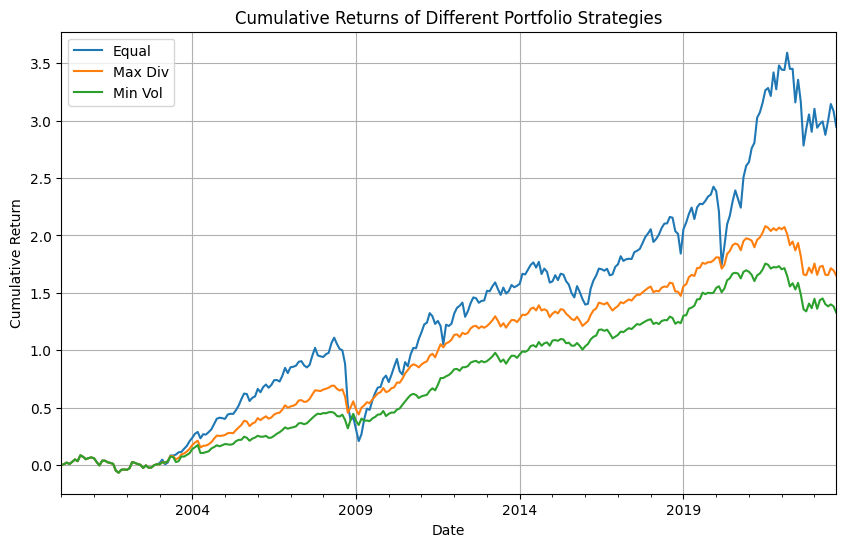

In [266]:
cumulative_returns = (1 + returns).cumprod() - 1
cumulative_returns .plot(figsize=(10, 6))
plt.title('Cumulative Returns of Different Portfolio Strategies')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left')
plt.grid()
plt.show()

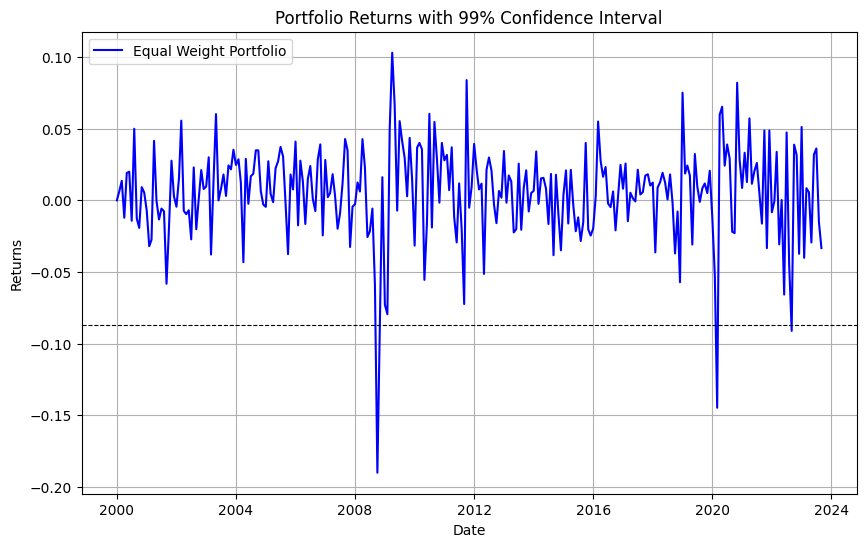

In [267]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns['Equal'], label='Equal Weight Portfolio', color='blue')
plt.axhline(y= returns['Equal'].quantile(0.01), color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

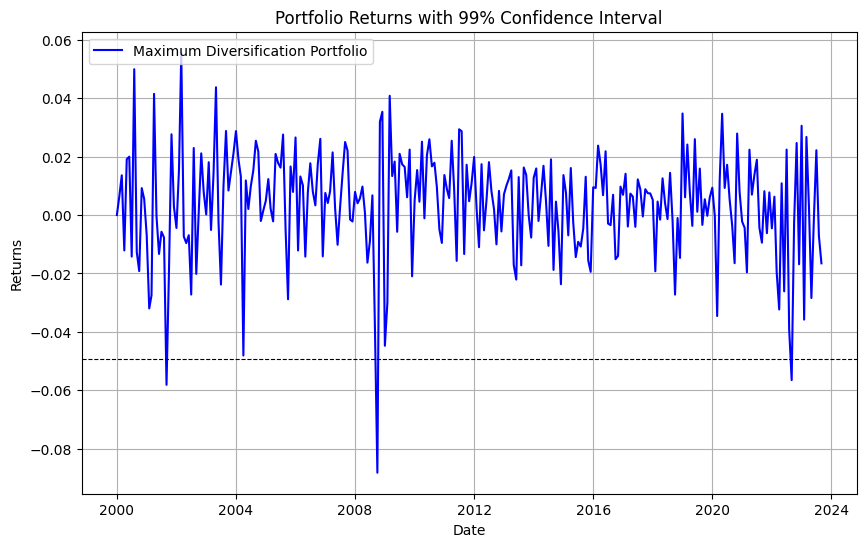

In [268]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns['Max Div'], label='Maximum Diversification Portfolio', color='blue')
plt.axhline(y= returns['Max Div'].quantile(0.01) , color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

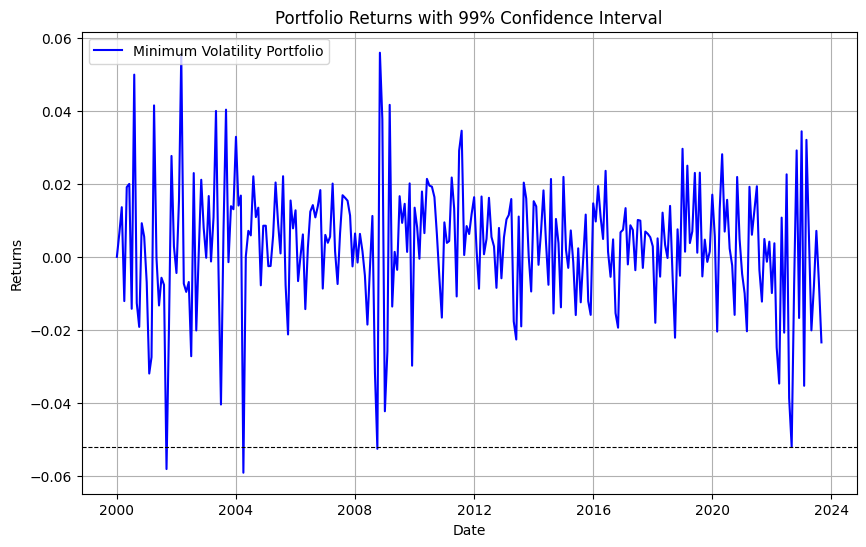

In [269]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns['Min Vol'], label='Minimum Volatility Portfolio', color='blue')
plt.axhline(y= returns['Min Vol'].quantile(0.01), color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

In [270]:
backtest_period = 36  # months
returns_1 = pd.DataFrame()

for i in range(len(monthly_returns)):
    if i < backtest_period:
        w1 = [0.25, 0.25, 0.25, 0.25]
        w2 = w1
        w3 = w1
    else:
        if i % backtest_period == 0:
            print(f"Backtesting period {i // backtest_period + 1} of {len(monthly_returns) // backtest_period}")
            rolling_window = monthly_returns.iloc[i - backtest_period:i]
            
            w1 = [0.25, 0.25, 0.25, 0.25]
            w2 = maximum_diversification_portfolio(rolling_window)
            w3 = minimum_volatility_portfolio(rolling_window)
            w1 = np.array(w1)
            w2 = np.array(w2)
            w3 = np.array(w3)
        
    portfolio_returns_equal_1 = np.dot(monthly_returns.iloc[i], w1)
    portfolio_returns_max_div_1 = np.dot(monthly_returns.iloc[i], w2)
    portfolio_returns_min_vol_1 = np.dot(monthly_returns.iloc[i], w3)
    
    
    new_row = pd.DataFrame([[portfolio_returns_equal, portfolio_returns_max_div, portfolio_returns_min_vol]],
                           columns=['Equal', 'Max Div', 'Min Vol'], index=[monthly_returns.index[i]])
    returns_1 = pd.concat([returns, new_row])

returns_1.index = pd.to_datetime(returns_1.index)
    
    
display(returns_1.head())
display(returns_1.tail())

Backtesting period 2 of 7
Backtesting period 3 of 7
Backtesting period 4 of 7
Backtesting period 5 of 7
Backtesting period 6 of 7
Backtesting period 7 of 7
Backtesting period 8 of 7


,Equal,Max Div,Min Vol
2000-01-01,0.000000,0.000000,0.000000
2000-02-01,0.006651,0.006651,0.006651
2000-03-01,0.013613,0.013613,0.013613
2000-04-01,-0.012134,-0.012134,-0.012134
2000-05-01,0.019114,0.019114,0.019114


,Equal,Max Div,Min Vol
2023-06-01,0.031948,-0.000835,-0.007967
2023-07-01,0.036198,0.022196,0.007124
2023-08-01,-0.014918,-0.007111,-0.006965
2023-09-01,-0.033306,-0.016549,-0.023458
2023-09-01,-0.033306,-0.016549,-0.023458


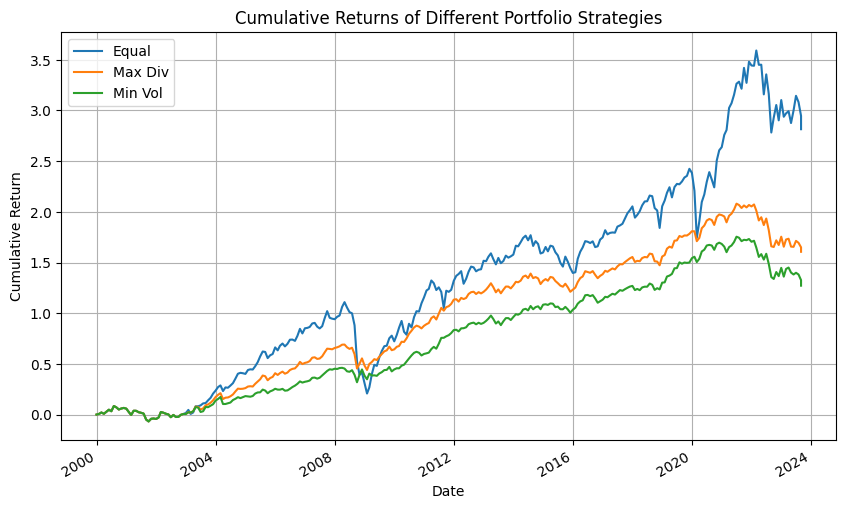

In [271]:
cumulative_returns_1 = (1 + returns_1).cumprod() - 1
cumulative_returns_1.plot(figsize=(10, 6))
plt.title('Cumulative Returns of Different Portfolio Strategies')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left')
plt.grid()
plt.show()

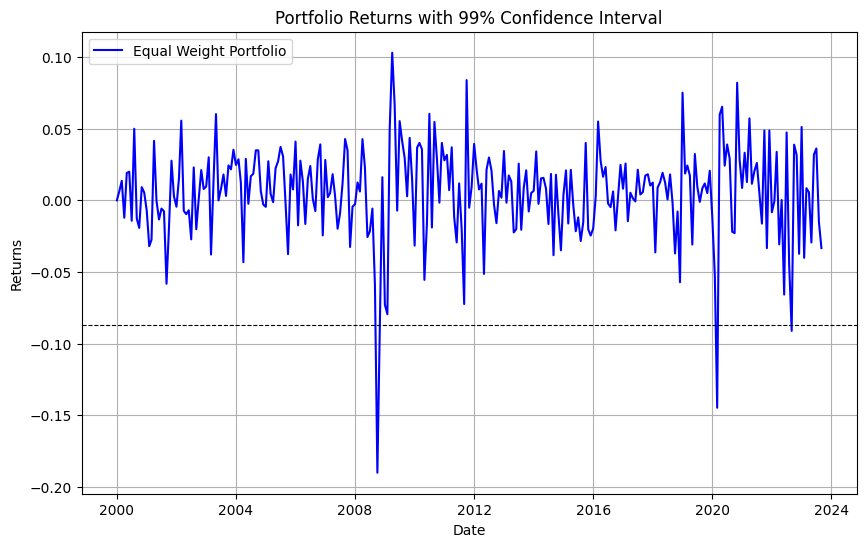

In [272]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns_1['Equal'], label='Equal Weight Portfolio', color='blue')
plt.axhline(y= returns['Equal'].quantile(0.01), color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

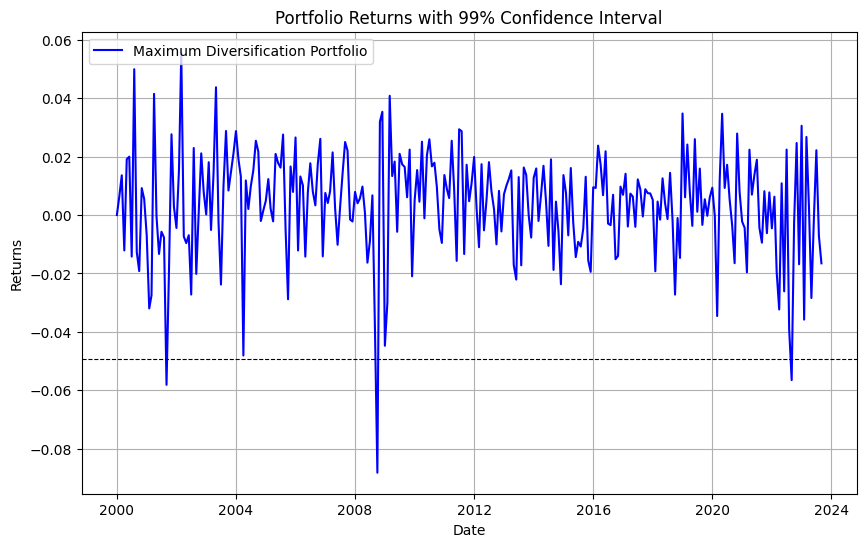

In [273]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns_1['Max Div'], label='Maximum Diversification Portfolio', color='blue')
plt.axhline(y= returns['Max Div'].quantile(0.01) , color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

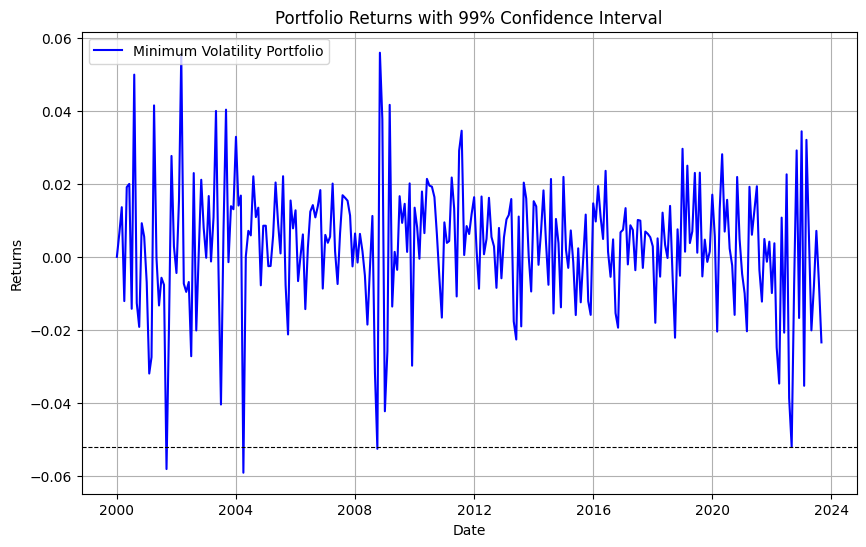

In [274]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns_1['Min Vol'], label='Minimum Volatility Portfolio', color='blue')
plt.axhline(y= returns['Min Vol'].quantile(0.01), color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()